*Nombre de Grupos*:

*Integrantes*:

# **Laboratorio 2: Convolucion, Filtros, Ruido y Bordes**

❗❗❗❗ ***Las imágenes necesarias (`ojoMandril.png` e `imagenDePruebaPSF.png`) se descargan automáticamente desde GitHub ejecutando la siguiente celda.*** ❗❗❗❗


In [1]:
import unittest
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters

# Descarga automática de imágenes para Google Colab y entorno local
!mkdir -p /content/imagenes imagenes
!wget -q -N https://raw.githubusercontent.com/StrawEater/PracticasPDI3erBimestre/main/imagenes/ojoMandril.png -P /content/imagenes/
!wget -q -N https://raw.githubusercontent.com/StrawEater/PracticasPDI3erBimestre/main/imagenes/imagenDePruebaPSF.png -P /content/imagenes/
!wget -q -N https://raw.githubusercontent.com/StrawEater/PracticasPDI3erBimestre/main/imagenes/ojoMandril.png -P imagenes/
!wget -q -N https://raw.githubusercontent.com/StrawEater/PracticasPDI3erBimestre/main/imagenes/imagenDePruebaPSF.png -P imagenes/

# Fallback por si wget no estuviera disponible (ej. en ciertos entornos de Windows sin bash)
import os
import urllib.request

urls = {
    'ojoMandril.png': 'https://raw.githubusercontent.com/StrawEater/PracticasPDI3erBimestre/main/imagenes/ojoMandril.png',
    'imagenDePruebaPSF.png': 'https://raw.githubusercontent.com/StrawEater/PracticasPDI3erBimestre/main/imagenes/imagenDePruebaPSF.png'
}
for fname, url in urls.items():
    for folder in ['/content/imagenes', 'imagenes']:
        try:
            os.makedirs(folder, exist_ok=True)
            fpath = os.path.join(folder, fname)
            if not os.path.exists(fpath):
                urllib.request.urlretrieve(url, fpath)
        except Exception:
            pass
print('Imágenes verificadas y listas.')


La sintaxis del comando no es correcta.
"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


Imágenes verificadas y listas.


"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


Muchas de las técnicas que abordaremos se basan en la modificación de un píxel en relación con sus vecinos. Cuando esta transformación es constante a lo largo de la imagen, podemos expresarla utilizando una segunda imagen, $h$, que define la relación entre la vecindad. A esta operación la llamaremos **convolución**, y se denotará de la siguiente manera:

$$
m \ast h
$$

donde $m$ representa la imagen original y se leerá como: "**$m$ convolucionada con $h$**".

Aunque en su mayoría trabajaremos con convoluciones de señales 2D, esta operación también existe y se utiliza de forma análoga en otras dimensiones. Para entender mejor su funcionamiento, comenzaremos trabajando con señales 1D, lo cual nos ayudará a desarrollar la intuición necesaria para abordar la versión 2D.



## ***Convolución 1D***


Para entender la convolución, primero es útil definir la **Delta de Kronecker**, que será fundamental para comprender cómo funciona esta operación.

La **Delta de Kronecker** es una señal que toma el valor 1 cuando su argumento es 0, y 0 en cualquier otro caso:

$$
\delta(x) =
\begin{cases}
1 & \text{si } x = 0 \\
0 & \text{si } x \neq 0
\end{cases}
$$

### **Representación de una señal como combinación lineal**

Imaginemos que tenemos la señal:

$$ S = [1, 2, 3, 4] $$

Podemos expresar cada elemento de la señal como una combinación lineal de los elementos originales, utilizando coeficientes que se van trasladando hacia la derecha. Es decir, cada valor de $S[n]$ depende de los valores anteriores y posteriores en la secuencia, de acuerdo con la siguiente fórmula:

* $ S[0] = 1 \cdot 1 + 2 \cdot 0 + 3 \cdot 0 + 4 \cdot 0$
* $ S[1] = 1 \cdot 0 + 2 \cdot 1 + 3 \cdot 0 + 4 \cdot 0$
* $ S[2] = 1 \cdot 0 + 2 \cdot 0 + 3 \cdot 1 + 4 \cdot 0$
* $ S[3] = 1 \cdot 0 + 2 \cdot 0 + 3 \cdot 0 + 4 \cdot 1$

Esta representación puede entenderse como una ***convolución*** de la señal $S$ con una señal formada solo por ceros y unos.

Para formalizar esta idea, podemos escribir la señal **$S$** como una combinación lineal infinita de desplazamientos de la señal original, utilizando la **Delta de Kronecker**:

$$
S[n] = \sum_{i=-\infty}^{+\infty} S[i] \cdot \delta(n - i)
$$

Donde los valores de $S[i]$ fuera de su rango están considerados como 0.



### **Definición de la Convolución**
Con este concepto en mente, podemos definir la **convolución** entre dos señales, $S$ y $h$, como:
$$
(S \ast h) [n] = \sum_{i=-\infty}^{+\infty} S[i] \cdot h(n - i)
$$
Aquí, la Delta de Kronecker actúa como el **elemento neutro** para la convolución. Es importante notar que la señal $h$ se invierte y cada uno de sus elementos se aplica sobre los elementos de $S$, desplazándose a lo largo de toda la señal y combinando los valores.


### **Intuición como Filtro**
La convolución puede interpretarse como un "deslizamiento" del filtro $h$ a lo largo de la señal $S$. En cada paso, se calcula un valor ponderado de $S$ según los coeficientes de $h$. Este proceso genera una nueva señal $S \ast h$, que contiene la "versión filtrada" de la señal original.


### **Ejercicio 1**: Implementar Convolución 1D


In [2]:
# Notar que el resultado de la convolucion tendra el tamaño (h - 1) + s
# Pueden utilizar h[::-1] para conseguir una view invertida de h
def convolucion1D(s, h):
  res = np.zeros((h.size - 1) + s.size)
  
  
  for i in range(0, res.size):
    #print(f'Coordenada {i}')
    
    for j in range(s.size):
      
      if i-j<0 or i-j>=h.size:
        res[i] += s[j] * 0
        #print(f'Cuenta: s[{j}] * h[{i-j}] = 0')
        
      else:
        res[i] += s[j] * h[i-j]
        #print(f'Cuenta: s[{j}] * h[{i-j}] = {s[j]}*{h[i-j]}')
        
  return res


In [3]:
h = np.array([2,3])
s = np.array([1,4,2])

print(f'{convolucion1D(s,h)}')

[ 2. 11. 16.  6.]


#### Tests:

In [4]:
class TestConvolucion1D(unittest.TestCase):

    def test_tamano_salida(self):
        # El tamaño de la convolución 1D debe ser len(s) + len(h) - 1
        s = np.array([1, 2, 3])
        h = np.array([0.5, 1.0])
        res = convolucion1D(s, h)
        self.assertEqual(len(res), len(s) + len(h) - 1, f"El tamaño esperado es {len(s) + len(h) - 1}, pero se obtuvo {len(res)}")

    def test_delta_identidad(self):
        # Convolucionar con un impulso unitario en posición 0 (delta) debe mantener la señal intacta
        s = np.array([1.0, 5.0, 3.0, 9.0])
        h = np.array([1.0])
        res = convolucion1D(s, h)
        np.testing.assert_allclose(res, s, err_msg="Convolución con delta [1.0] debería devolver la misma señal")

    def test_convolucion_constante(self):
        # Probar una convolución sencilla calculada a mano
        s = np.array([1.0, 1.0, 1.0])
        h = np.array([1.0, 1.0])
        esperado = np.array([1.0, 2.0, 2.0, 1.0])
        res = convolucion1D(s, h)
        np.testing.assert_allclose(res, esperado, err_msg="El resultado de la convolución no coincide con el valor esperado")

    def test_conmutatividad(self):
        # convolucion1D(s, h) debe ser igual a convolucion1D(h, s)
        s = np.array([1.0, 2.0, 4.0, 8.0])
        h = np.array([0.2, 0.5, 0.3])
        res1 = convolucion1D(s, h)
        res2 = convolucion1D(h, s)
        np.testing.assert_allclose(res1, res2, err_msg="La convolución 1D debe ser conmutativa (s * h == h * s)")

    def test_comparacion_scipy(self):
        # Comparar con np.convolve(s, h, mode='full')
        s = np.array([0, 1, 5, 3, 9, 0, 1, 0], dtype=float)
        h = np.array([0.25, 0.5, 0.25], dtype=float)
        res_propio = convolucion1D(s, h)
        res_np = np.convolve(s, h, mode='full')
        np.testing.assert_allclose(res_propio, res_np, atol=1e-5, err_msg="El resultado difiere de np.convolve")

if __name__ == '__main__':
    suite = unittest.TestLoader().loadTestsFromTestCase(TestConvolucion1D)
    resultado = unittest.TextTestRunner(verbosity=0).run(suite)
    if resultado.wasSuccessful():
        print("Todos los tests de Convolución 1D pasaron correctamente.")
    else:
        print("Algunos tests de Convolución 1D fallaron. Revisá la implementación.")


----------------------------------------------------------------------
Ran 5 tests in 0.017s

OK


Todos los tests de Convolución 1D pasaron correctamente.


#### **Ejemplos de Convolución 1D**
Antes de ver el resultado de la convolución, vean las dos señales por si solas y piensen qué forma tendrá la señal de salida, pueden intentar dibujarlas.
Jueguen con las señales de entrada hasta entender qué es lo que está sucediendo atrás y por qué se llegan a estos resultados.


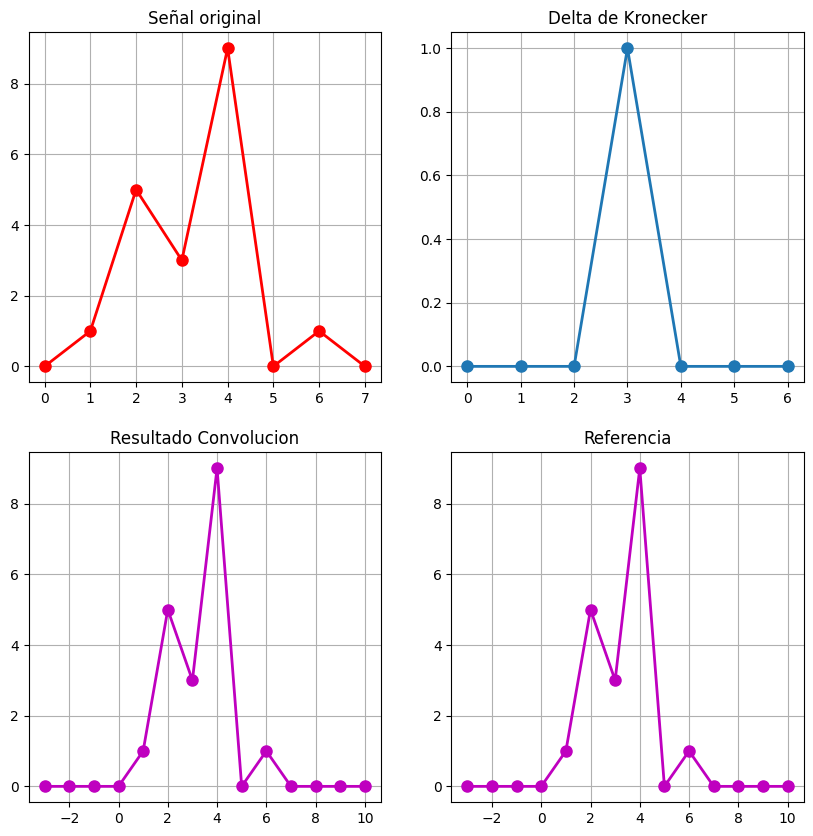

In [5]:

delta = np.asarray([0,0,0,1,0,0,0])
s = np.asarray([0,1,5,3,9,0,1,0])

resConvolucion = convolucion1D(s, delta)
# Convolucion de referencia
scipyConvolucion = np.convolve(s, delta)

# El origen de la señal de filtro sera su medio, por eso siempre trabajaremos
# con filtros de longitud impar.
ejeX = range(-delta.size // 2 + 1, s.size + delta.size // 2)

fig, ax = plt.subplots(2,2,figsize=(10,10))
ax = np.ravel(ax)

ax[0].set_title("Señal original")
ax[0].grid(True)
ax[0].plot(s, marker='o', color='r', linestyle='-', linewidth=2, markersize=8)

ax[1].set_title("Delta de Kronecker")
ax[1].grid(True)
ax[1].plot(delta,marker='o', linestyle='-', linewidth=2, markersize=8)

ax[2].set_title("Resultado Convolucion")
ax[2].grid(True)
ax[2].plot(ejeX, resConvolucion, marker='o', color='m', linestyle='-', linewidth=2, markersize=8)

ax[3].set_title("Referencia")
ax[3].grid(True)
ax[3].plot(ejeX, scipyConvolucion, marker='o', color='m', linestyle='-', linewidth=2, markersize=8)
plt.show()


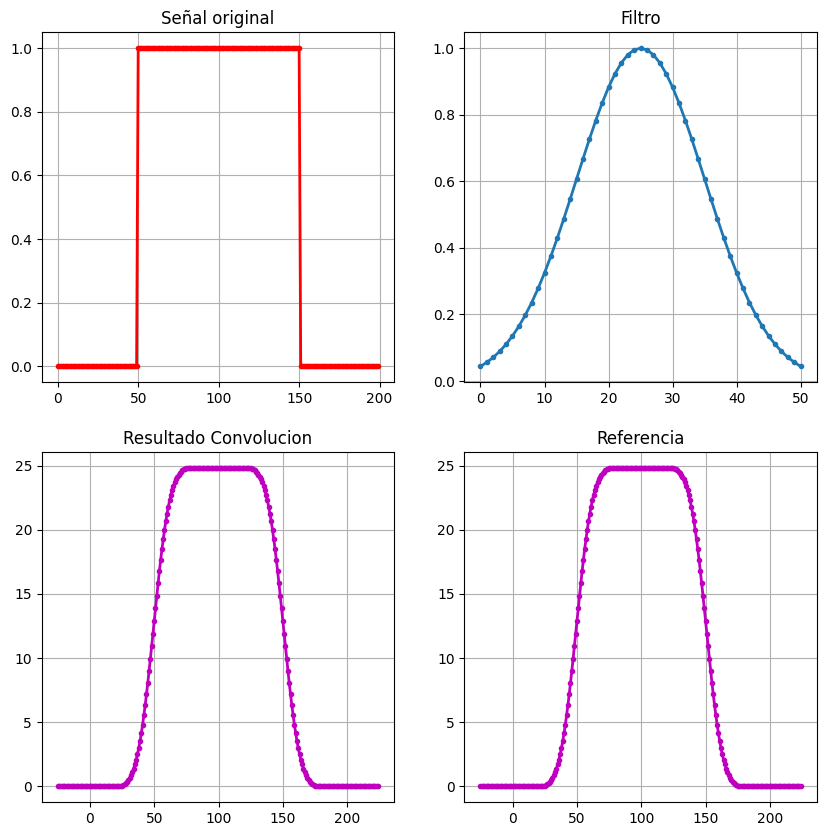

In [6]:
from scipy import signal

gauss = signal.windows.gaussian(51, std=10)

#Creamos una señal cuadrada
s = np.zeros(200)
s[50:151] = 1

resConvolucion = convolucion1D(s, gauss)
# Convolucion de referencia
scipyConvolucion = np.convolve(s, gauss)

# El origen de la señal de filtro sera su medio, por eso siempre trabajaremos
# con filtros de longitud impar.
ejeX = range(-gauss.size // 2 + 1, s.size + gauss.size // 2)

fig, ax = plt.subplots(2,2,figsize=(10,10))
ax = np.ravel(ax)

ax[0].set_title("Señal original")
ax[0].grid(True)
ax[0].plot(s, marker='o', color='r', linestyle='-', linewidth=2, markersize=3)

ax[1].set_title("Filtro")
ax[1].grid(True)
ax[1].plot(gauss,marker='o', linestyle='-', linewidth=2, markersize=3)

ax[2].set_title("Resultado Convolucion")
ax[2].grid(True)
ax[2].plot(ejeX, resConvolucion, marker='o', color='m', linestyle='-', linewidth=2, markersize=3)

ax[3].set_title("Referencia")
ax[3].grid(True)
ax[3].plot(ejeX, scipyConvolucion, marker='o', color='m', linestyle='-', linewidth=2, markersize=3)
plt.show()

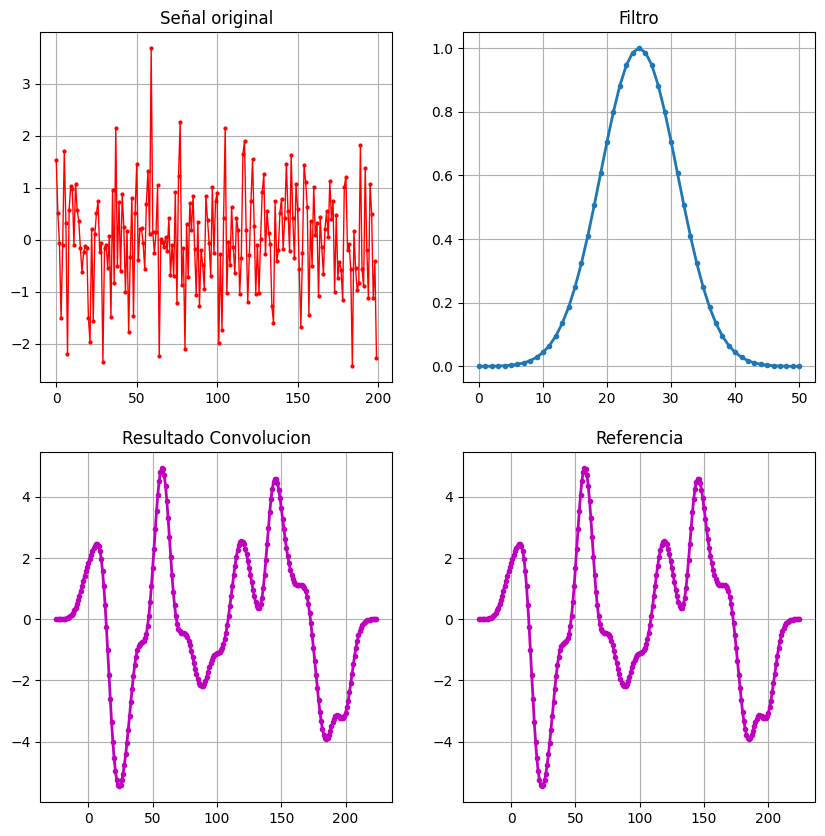

In [7]:
from scipy import signal

# Creamos una señal gaussiana
gauss = signal.windows.gaussian(51, std=6)

#Creamos una señal aleatoria
s = np.random.randn(200)

resConvolucion = convolucion1D(s, gauss)
# Convolucion de referencia
scipyConvolucion = np.convolve(s, gauss)

# El origen de la señal de filtro sera su medio, por eso siempre trabajaremos
# con filtros de longitud impar.
ejeX = range(-gauss.size // 2 + 1, s.size + gauss.size // 2)

fig, ax = plt.subplots(2,2,figsize=(10,10))
ax = np.ravel(ax)

ax[0].set_title("Señal original")
ax[0].grid(True)
ax[0].plot(s, marker='o', color='r', linestyle='-', linewidth=1, markersize=2)

ax[1].set_title("Filtro")
ax[1].grid(True)
ax[1].plot(gauss,marker='o', linestyle='-', linewidth=2, markersize=3)

ax[2].set_title("Resultado Convolucion")
ax[2].grid(True)
ax[2].plot(ejeX, resConvolucion, marker='o', color='m', linestyle='-', linewidth=2, markersize=3)

ax[3].set_title("Referencia")
ax[3].grid(True)
ax[3].plot(ejeX, scipyConvolucion, marker='o', color='m', linestyle='-', linewidth=2, markersize=3)
plt.show()

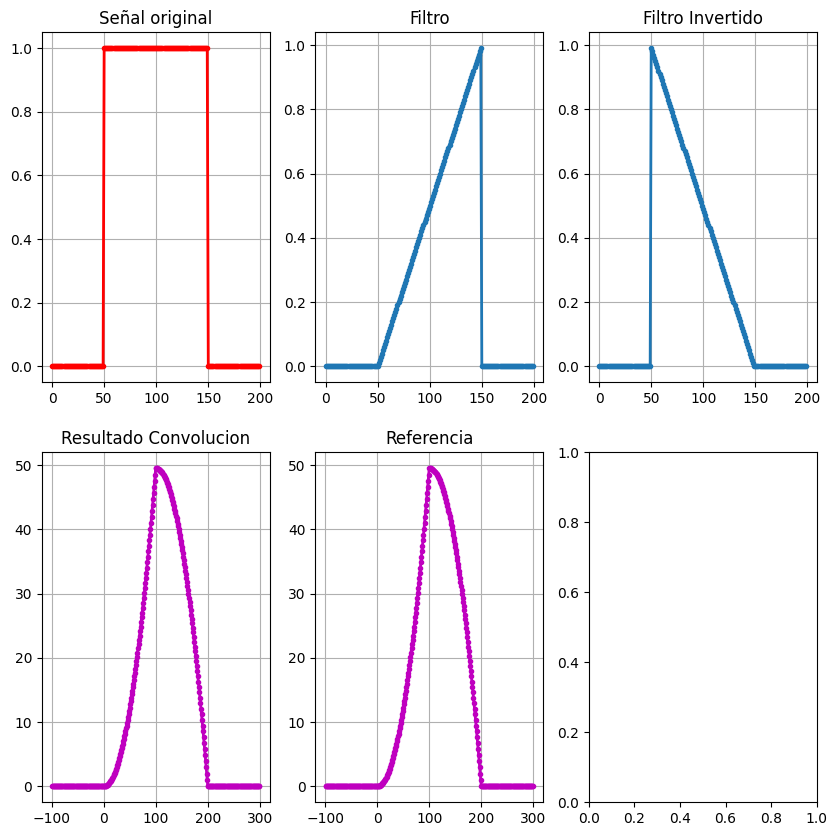

In [8]:
from scipy import signal

#Creamos una señal sierra
h = np.zeros(200)
h[50:150] = np.arange(0,1,0.01)

#Creamos una señal cuadrada
s = np.zeros(200)
s[50:150] = 1

resConvolucion = convolucion1D(s, h)
# Convolucion de referencia
scipyConvolucion = np.convolve(s, h)

# El origen de la señal de filtro sera su medio, por eso siempre trabajaremos
# con filtros de longitud impar.
ejeX = range(-h.size // 2 + 1, s.size + h.size // 2)


fig, ax = plt.subplots(2,3,figsize=(10,10))
ax = np.ravel(ax)

ax[0].set_title("Señal original")
ax[0].grid(True)
ax[0].plot(s, marker='o', color='r', linestyle='-', linewidth=2, markersize=3)

ax[1].set_title("Filtro")
ax[1].grid(True)
ax[1].plot(h,marker='o', linestyle='-', linewidth=2, markersize=3)

ax[2].set_title("Filtro Invertido")
ax[2].grid(True)
ax[2].plot(h[::-1],marker='o', linestyle='-', linewidth=2, markersize=3)


ax[3].set_title("Resultado Convolucion")
ax[3].grid(True)
ax[3].plot(ejeX, resConvolucion, marker='o', color='m', linestyle='-', linewidth=2, markersize=3)

ax[4].set_title("Referencia")
ax[4].grid(True)
ax[4].plot(ejeX, scipyConvolucion, marker='o', color='m', linestyle='-', linewidth=2, markersize=3)
plt.show()

### **Ejercicio 2**: Implementar convolución por fila
Dada una imagen y un filtro, devolver la imagen resultante de convolucionar cada fila con el filtro.


In [9]:
def convolucionPorFila(imagen, filtro):
  # COMPLETAR
  imagenRes = np.zeros((imagen.shape[0],imagen.shape[1]+ filtro.size - 1))
  
  for i in range(imagenRes.shape[0]):
    imagenRes[i] = convolucion1D(imagen[i], filtro) 
  
  return imagenRes


#### Tests:

In [10]:
class TestConvolucionPorFila(unittest.TestCase):

    def test_tamano_salida(self):
        # La salida debe tener forma (filas, cols + len(filtro) - 1)
        img = np.zeros((10, 20))
        filtro = np.array([1, 2, 3])
        res = convolucionPorFila(img, filtro)
        esperado_shape = (10, 20 + 3 - 1)
        self.assertEqual(res.shape, esperado_shape, f"Forma esperada {esperado_shape}, obtenida {res.shape}")

    def test_filas_independientes(self):
        # Cada fila resultante debe coincidir exactamente con convolucion1D de esa fila
        img = np.random.rand(5, 15)
        filtro = np.array([0.5, 1.0, 0.5])
        res = convolucionPorFila(img, filtro)
        for i in range(img.shape[0]):
            esperado_fila = np.convolve(img[i], filtro, mode='full')
            np.testing.assert_allclose(res[i], esperado_fila, atol=1e-5, err_msg=f"Fallo en la fila {i}")

    def test_filtro_delta(self):
        # Filtro delta [1.0] no modifica el contenido de las filas
        img = np.array([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
        filtro = np.array([1.0])
        res = convolucionPorFila(img, filtro)
        np.testing.assert_allclose(res, img, err_msg="Convolución por fila con filtro delta [1.0] debe devolver la imagen original")

if __name__ == '__main__':
    suite = unittest.TestLoader().loadTestsFromTestCase(TestConvolucionPorFila)
    resultado = unittest.TextTestRunner(verbosity=0).run(suite)
    if resultado.wasSuccessful():
        print("Todos los tests de Convolución por Fila pasaron correctamente.")
    else:
        print("Algunos tests de Convolución por Fila fallaron. Revisá la implementación.")


----------------------------------------------------------------------
Ran 3 tests in 0.005s

OK


Todos los tests de Convolución por Fila pasaron correctamente.


#### **Ejemplos de Convolución por fila**


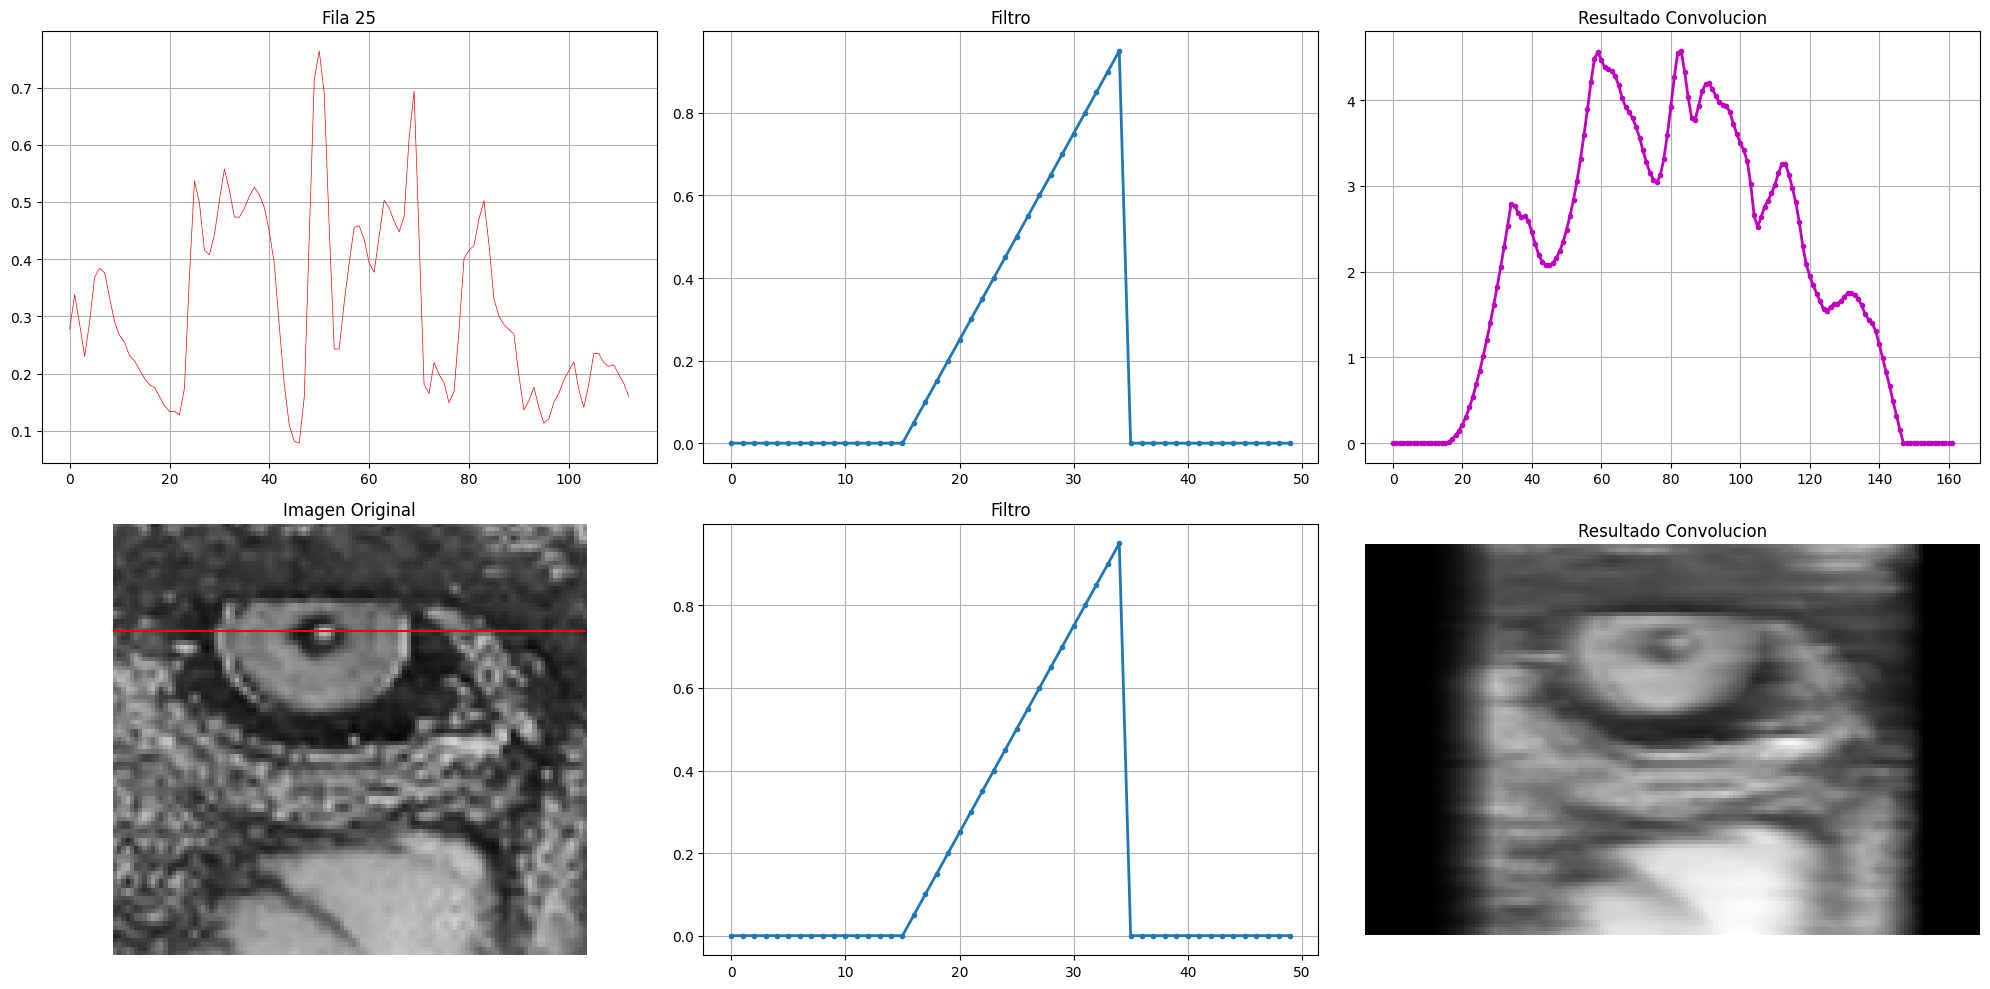

In [11]:
from skimage import data, util, exposure,io
# Utilizamos un tipo de dato con mayor precision para no tener problemas en la convolucion
imagenOriginal = util.img_as_float32(io.imread("/content/imagenes/ojoMandril.png" if os.path.exists("/content/imagenes/ojoMandril.png") else "imagenes/ojoMandril.png", as_gray=True))
# Fila para ver UN resultado individual de la convolucion
FILA_MUESTRA = 25
filaImagen = imagenOriginal[FILA_MUESTRA,:]
# Creamos una señal sierra
filtro = np.zeros(50)
filtro[15:35] = np.arange(0,1,0.05)
#Convolucionamos la fila individual
filaConvolucionada = convolucion1D(filaImagen, filtro)
# Convolucionamos por fila a toda la imagen
# Ajustamos el rango para acabar en un rango valido
imagenConvolucionada = convolucionPorFila(imagenOriginal, filtro)
imagenConvolucionada = exposure.rescale_intensity(imagenConvolucionada,
                                                  in_range=(imagenConvolucionada.min(), imagenConvolucionada.max()),
                                                  out_range=(0, 1))
# Mostramos el resultado
fig, axs = plt.subplots(2,3, figsize=(20,10))
axs = np.ravel(axs)
axs[0].set_title(f"Fila {FILA_MUESTRA}")
axs[0].grid(True)
axs[0].plot(filaImagen, color='r', linestyle='-', linewidth=0.5)
axs[1].set_title("Filtro")
axs[1].grid(True)
axs[1].plot(filtro, marker='o', linestyle='-', linewidth=2, markersize=3)
axs[2].set_title("Resultado Convolucion")
axs[2].grid(True)
axs[2].plot(filaConvolucionada, marker='o', color='m', linestyle='-', linewidth=2, markersize=3)
axs[3].imshow(imagenOriginal, cmap='gray', clim=(0,1))
axs[3].axhline(y=FILA_MUESTRA, color='r', linestyle='-')
axs[3].set_title("Imagen Original")
axs[3].axis("off")
axs[4].set_title("Filtro")
axs[4].grid(True)
axs[4].plot(filtro, marker='o', linestyle='-', linewidth=2, markersize=3)
axs[5].imshow(imagenConvolucionada, cmap='gray', clim=(0,1))
axs[5].set_title("Resultado Convolucion")
axs[5].axis("off")
plt.tight_layout()
plt.show()


## ***CHECKPOINT 1 !!!***

## **Convolución 2D**

Al igual que en la convolución 1D, podemos interpretar las imágenes como combinaciones lineales de sus valores, pero ahora trabajaremos en un espacio bidimensional.


### **Delta de Kronecker en 2D**
Para comenzar, veamos cómo la **delta de Kronecker** se extiende a dos dimensiones de la siguiente manera:
$$
\delta(x, y) =
\begin{cases}
1 & \text{si } x = 0 \text{ y } y = 0 \\
0 & \text{si } x \neq 0 \text{ o } y \neq 0
\end{cases}
$$
Esta imagen otra vez servirá como el **elemento neutro** en nuestras definiciones.


### **Representación de una imagen como combinación lineal**
Supongamos que tenemos una imagen $M$ representada de la siguiente manera:
$$
M =
\begin{bmatrix}
A & B \\
C & D
\end{bmatrix}
$$
Podemos reescribir esta imagen como una combinación lineal de sus componentes, similar a lo que hicimos en la convolución 1D. Cada elemento de la imagen se obtiene al multiplicar cada valor por un 0 o 1:
- $M[0,0] = A \cdot 1 + B \cdot 0 + C \cdot 0 + D \cdot 0$
- $M[0,1] = A \cdot 0 + B \cdot 1 + C \cdot 0 + D \cdot 0$
- $M[1,0] = A \cdot 0 + B \cdot 0 + C \cdot 1 + D \cdot 0$
- $M[1,1] = A \cdot 0 + B \cdot 0 + C \cdot 0 + D \cdot 1$
Podemos verlo como el resultado de una **convolución** de una imagen compuesta por 1 y 0s. Utilizando la Delta de Kronecker podríamos escribir:
$$
M[n,m] = \sum_{i=-\infty}^{+\infty}\sum_{j=-\infty}^{+\infty} M[i][j] \cdot \delta(n - i, m - i)
$$


### **Definición de la Convolución 2D**
Ahora, introduzcamos la **convolución 2D**. Al igual que en la convolución 1D, podemos definir la convolución entre dos señales, $M$ y $h$, de la siguiente manera:
$$
M[n,m] = \sum_{i=-\infty}^{\infty} \sum_{j=-\infty}^{\infty} M[i,j] \cdot h(n - i, m - j)
$$
En esta fórmula, $M[i,j]$ son los valores de la imagen original, y $h$ es una función que se aplica sobre cada valor de $M$. La imagen $h$ es desplazada y girada 180 grados durante el proceso, lo que permite aplicar un filtro sobre la imagen original.


### **Intuición detrás de la Convolución 2D como Filtro**
Al igual que en 1D, la convolución puede pensarse como un **filtro**. En cada paso de la operación, calculamos un valor ponderado de los elementos de la imagen $M$ utilizando los coeficientes del **Filtro/Kernel** $h$ y los valores de los píxeles vecinos. Esto da como resultado una nueva imagen $M \ast h$, que es una versión filtrada de la imagen original.


### **Ejemplos de Convolución 2D**
Utilizaremos el método `ndimage.convolve` de la biblioteca scipy para realizar las convoluciones.


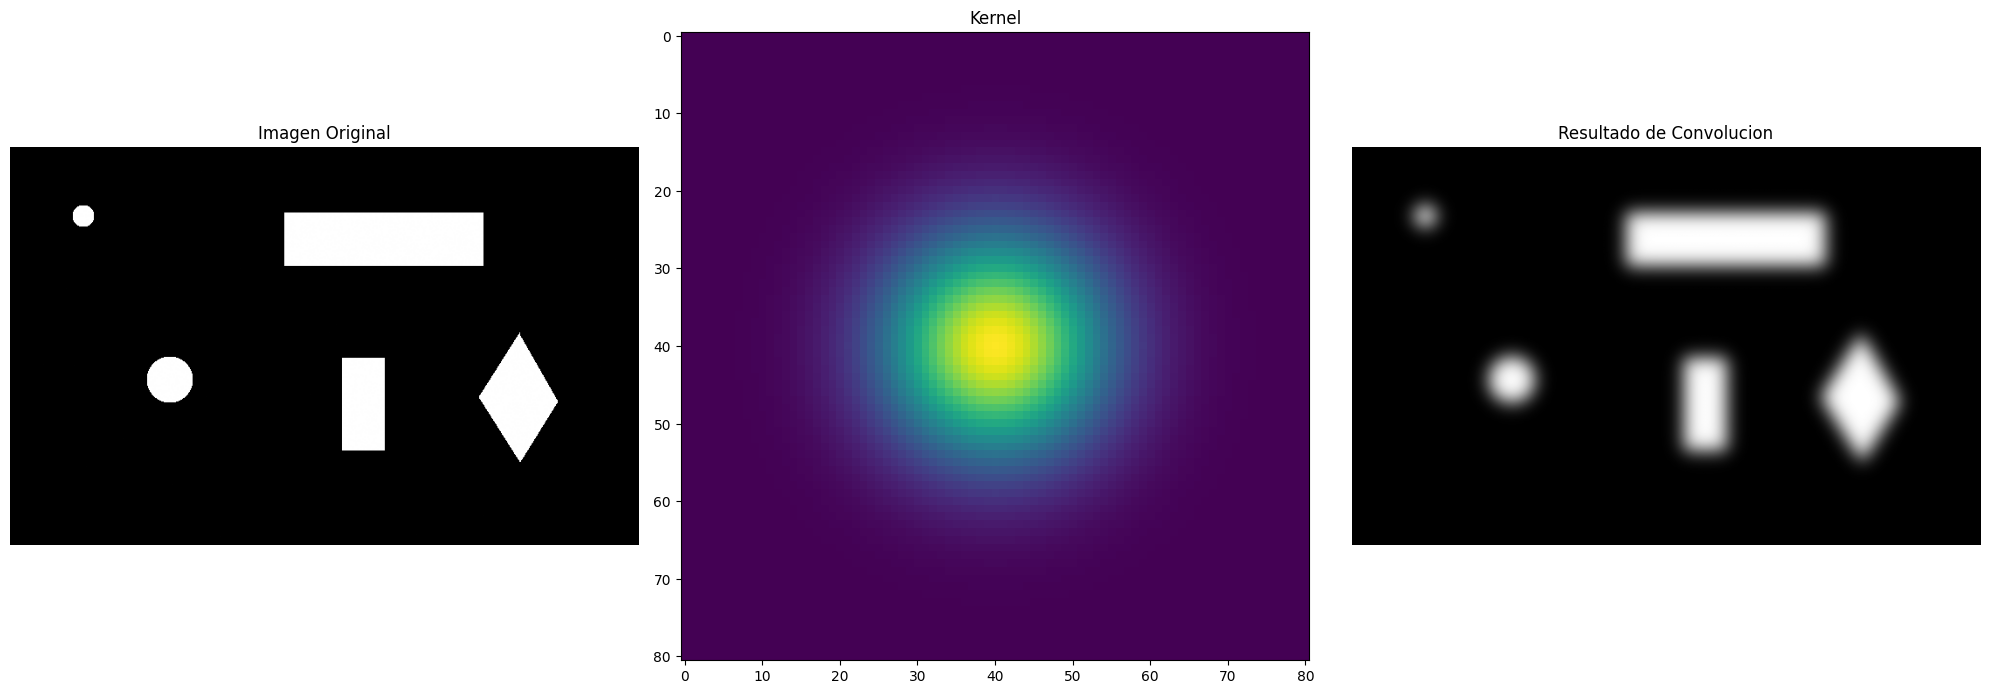

In [12]:
from skimage import data, util, exposure,io
from scipy import ndimage
def kernelDePrueba(x,y):
  # NO ES UNA GAUSSIANA (CUIDADO)
  return np.exp(-(x**2)/(2*(10)**2) - (y**2)/(2*(10)**2))
ejeX = np.arange(-40, 41)
ejeY = np.arange(-40, 41)
# Creamos un Kernel/filtro para aplicar sobre la imagen
X,Y = np.meshgrid(ejeX, ejeY)
kernel = kernelDePrueba(X, Y).T
imagenBlancoNegro = util.img_as_float32(io.imread("/content/imagenes/imagenDePruebaPSF.png" if os.path.exists("/content/imagenes/imagenDePruebaPSF.png") else "imagenes/imagenDePruebaPSF.png", as_gray=True))
# Realizamos la convolucion entre las imagenes
imagenConv = ndimage.convolve(imagenBlancoNegro, kernel)
imagenConv = exposure.rescale_intensity(imagenConv,
                                        in_range=(imagenConv.min(), imagenConv.max()),
                                                  out_range=(0, 1))
# Mostramos el resultado
fig, axs = plt.subplots(1,3, figsize=(20,10))
axs[0].imshow(imagenBlancoNegro, cmap='gray', clim=(0,1))
axs[0].set_title("Imagen Original")
axs[0].axis("off")
axs[1].imshow(kernel)
axs[1].set_title("Kernel")
axs[2].imshow(imagenConv, cmap='gray', clim=(0,1))
axs[2].set_title("Resultado de Convolucion")
axs[2].axis("off")
plt.tight_layout()
plt.show()


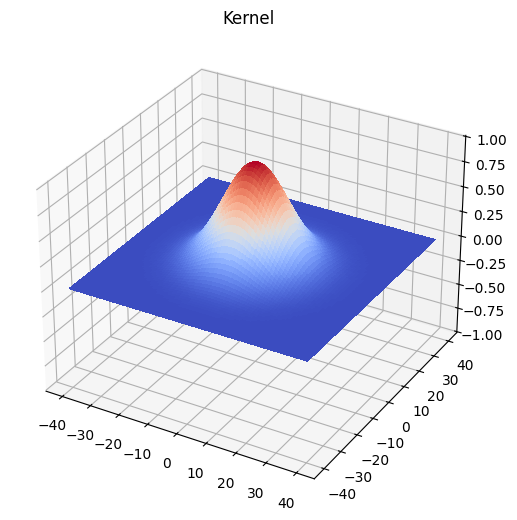

In [13]:
from matplotlib import cm

# Podemos ver al Kernel en 3d para entender mejor lo que sucede
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1, 2, 1, projection='3d')

surf = ax.plot_surface(X, Y, kernel, rstride=1, cstride=1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
ax.set_zlim(-1.01, 1.01)
ax.set_title("Kernel")
plt.tight_layout()
plt.show()

### **Ejercicio 3:** Implementar un filtro Gaussiano
Dada una imagen y un sigma, devolver la imagen resultante de haber convolucionado la imagen de entrada con la distribución de Gauss correspondiente. No es necesario que el filtro devuelva una imagen en el rango válido.


In [36]:
from skimage import filters
# Pueden utilizar la cuenta 2 * int(4 * sigma + 0.5) + 1 para conocer el tamaño correcto del Kernel
def filtroGaussiano(imagen, sigma):
  
  radio = 2 * int(4 * sigma + 0.5) + 1              
  coordenadas = np.arange(-radio, radio+1)      
  x, y = np.meshgrid(coordenadas, coordenadas)
  g_x = gauss1D(x, sigma)
  g_y = gauss1D(y, sigma)

  kernel = g_x * g_y 
  kernel_normalizado = kernel / np.sum(kernel)

  imagen_filtrada = ndimage.convolve(imagen, kernel_normalizado, mode='nearest')


  return imagen_filtrada
## Devuelve una distribucion Gaussiana con el sigma indicado.
## La usamos para plotear la gausseana utilizada en 1 dimension.
def gauss1D(x,sigma):
  return 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (x**2) / (2 * sigma**2))


#### Tests:

In [37]:
class TestFiltroGaussiano(unittest.TestCase):

    def test_dimensiones_y_tipo(self):
        # La imagen filtrada debe conservar las dimensiones de la imagen de entrada
        img = np.random.rand(50, 50).astype(np.float32)
        res = filtroGaussiano(img, sigma=2)
        self.assertEqual(res.shape, img.shape, "El filtro gaussiano debe mantener las dimensiones originales de la imagen")

    def test_imagen_uniforme(self):
        # Una imagen constante debe mantenerse constante tras el filtrado gaussiano
        img = np.full((30, 30), 0.5, dtype=np.float32)
        res = filtroGaussiano(img, sigma=3)
        np.testing.assert_allclose(res, img, atol=1e-3, err_msg="Una imagen uniforme no debería cambiar con el filtro gaussiano")

    def test_suavizado_ruido(self):
        # El filtrado gaussiano debe reducir la varianza de una imagen con ruido
        np.random.seed(42)
        img_ruido = np.random.normal(0.5, 0.2, (100, 100)).astype(np.float32)
        res = filtroGaussiano(img_ruido, sigma=3)
        self.assertLess(np.var(res), np.var(img_ruido), "El filtro gaussiano debería reducir la varianza (ruido) de la imagen")

    def test_comparacion_skimage(self):
        # Compara con skimage.filters.gaussian
        img = data.camera() / 255.0
        res_propio = filtroGaussiano(img, sigma=2)
        res_sk = filters.gaussian(img, sigma=2)
        np.testing.assert_allclose(res_propio, res_sk, atol=0.05, err_msg="El resultado difiere significativamente de skimage.filters.gaussian")

if __name__ == '__main__':
    suite = unittest.TestLoader().loadTestsFromTestCase(TestFiltroGaussiano)
    resultado = unittest.TextTestRunner(verbosity=0).run(suite)
    if resultado.wasSuccessful():
        print("Todos los tests del Filtro Gaussiano pasaron correctamente.")
    else:
        print("Algunos tests del Filtro Gaussiano fallaron. Revisá la implementación.")


----------------------------------------------------------------------
Ran 4 tests in 0.444s

OK


Todos los tests del Filtro Gaussiano pasaron correctamente.


#### **Ejemplo filtro gausseano**

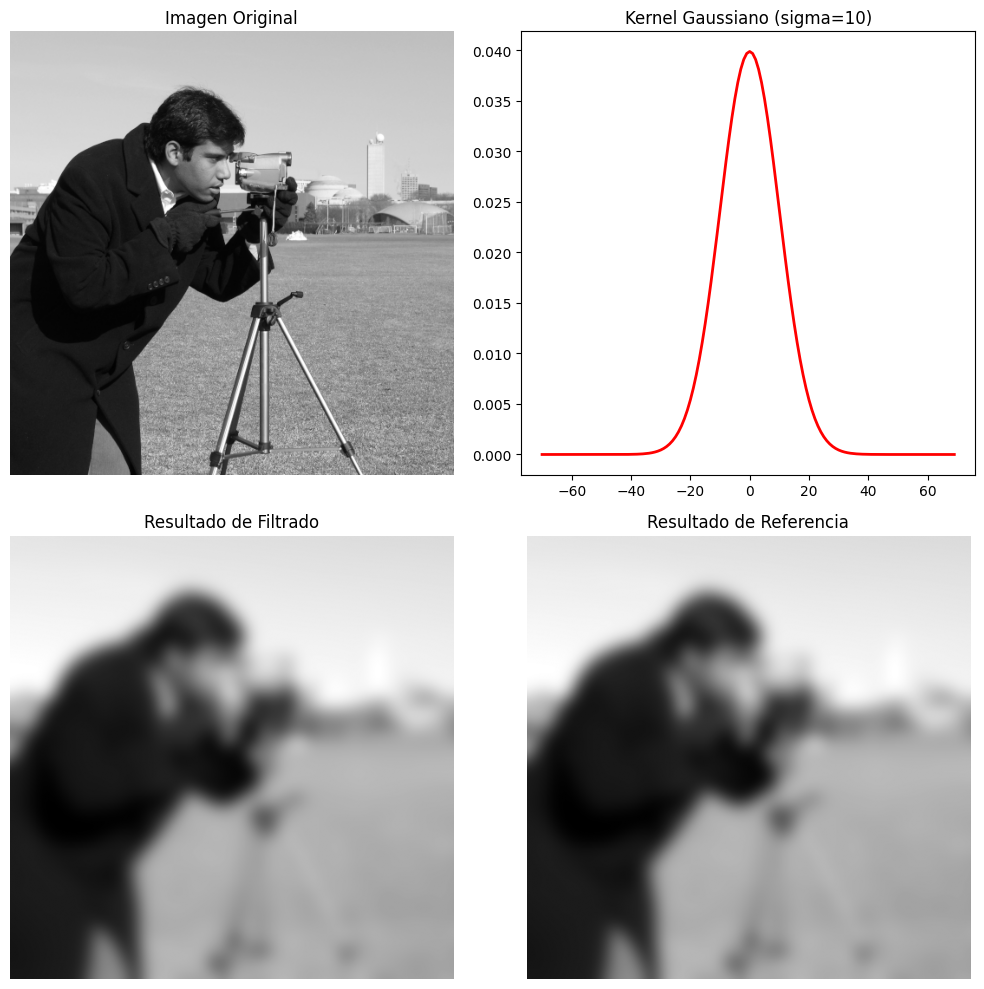

In [38]:

SIGMA = 10
imagenBlancoNegro = util.img_as_float32(data.camera())

# Filtramos la imagen
imagenFiltrada = filtroGaussiano(imagenBlancoNegro, SIGMA)
imagenFiltrada = exposure.rescale_intensity(imagenFiltrada,
                                        in_range=(imagenFiltrada.min(), imagenFiltrada.max()),
                                                  out_range=(0, 1))

# Resultado de Referencia
filtroReferencia = filters.gaussian(imagenBlancoNegro, SIGMA)
filtroReferencia = exposure.rescale_intensity(filtroReferencia,
                                        in_range=(filtroReferencia.min(), filtroReferencia.max()),
                                                  out_range=(0, 1))

# Mostramos el resultado
fig, axs = plt.subplots(2,2, figsize=(10,10))
axs = np.ravel(axs)

axs[0].imshow(imagenBlancoNegro, cmap='gray', clim=(0,1))
axs[0].set_title("Imagen Original")
axs[0].axis("off")

axs[1].plot(np.arange(-70,70), gauss1D(np.arange(-70,70), SIGMA), linewidth=2, color='r')
axs[1].set_title(f"Kernel Gaussiano (sigma={SIGMA})")

axs[2].imshow(imagenFiltrada, cmap='gray', clim=(0,1))
axs[2].set_title("Resultado de Filtrado")
axs[2].axis("off")

axs[3].imshow(filtroReferencia, cmap='gray', clim=(0,1))
axs[3].set_title("Resultado de Referencia")
axs[3].axis("off")

plt.tight_layout()
plt.show()

### **Ejercicio 4**: Implementar un filtro de Realce de Bordes.
Dada una imagen, devolver su versión con los bordes realzados utilizando Unsharp Masking


In [46]:
def SharpImage(image):

  image_suavizada = filtroGaussiano(image, 10)
  mascara = image - image_suavizada

  res = image + 2 * mascara
  
  return res

#### Tests:

In [47]:
class TestSharpImage(unittest.TestCase):

    def test_dimensiones(self):
        # Debe mantener la misma forma que la imagen original
        img = np.random.rand(40, 40).astype(np.float32)
        res = SharpImage(img)
        self.assertEqual(res.shape, img.shape, "SharpImage debe mantener el tamaño de la imagen original")

    def test_imagen_constante(self):
        # Una imagen uniforme sin bordes no se ve alterada por el realce de bordes
        img = np.full((30, 30), 0.4, dtype=np.float32)
        res = SharpImage(img)
        np.testing.assert_allclose(res, img, atol=1e-3, err_msg="Una imagen plana no debería cambiar tras el realce de bordes")

    def test_realce_bordes(self):
        # En una imagen con un borde escalón, el pixel brillante del borde se vuelve más brillante y el oscuro más oscuro
        img = np.zeros((20, 20), dtype=np.float32)
        img[:, 10:] = 1.0
        res = SharpImage(img)
        self.assertGreaterEqual(res[:, 10].max(), 1.0, "El realce debería incrementar la intensidad cerca del borde claro")
        self.assertLessEqual(res[:, 9].min(), 0.0, "El realce debería disminuir la intensidad cerca del borde oscuro")

if __name__ == '__main__':
    suite = unittest.TestLoader().loadTestsFromTestCase(TestSharpImage)
    resultado = unittest.TextTestRunner(verbosity=0).run(suite)
    if resultado.wasSuccessful():
        print("Todos los tests de SharpImage (Realce de Bordes) pasaron correctamente.")
    else:
        print("Algunos tests de SharpImage fallaron. Revisá la implementación.")


----------------------------------------------------------------------
Ran 3 tests in 1.049s

OK


Todos los tests de SharpImage (Realce de Bordes) pasaron correctamente.


#### **Ejemplo filtro que realza bordes**

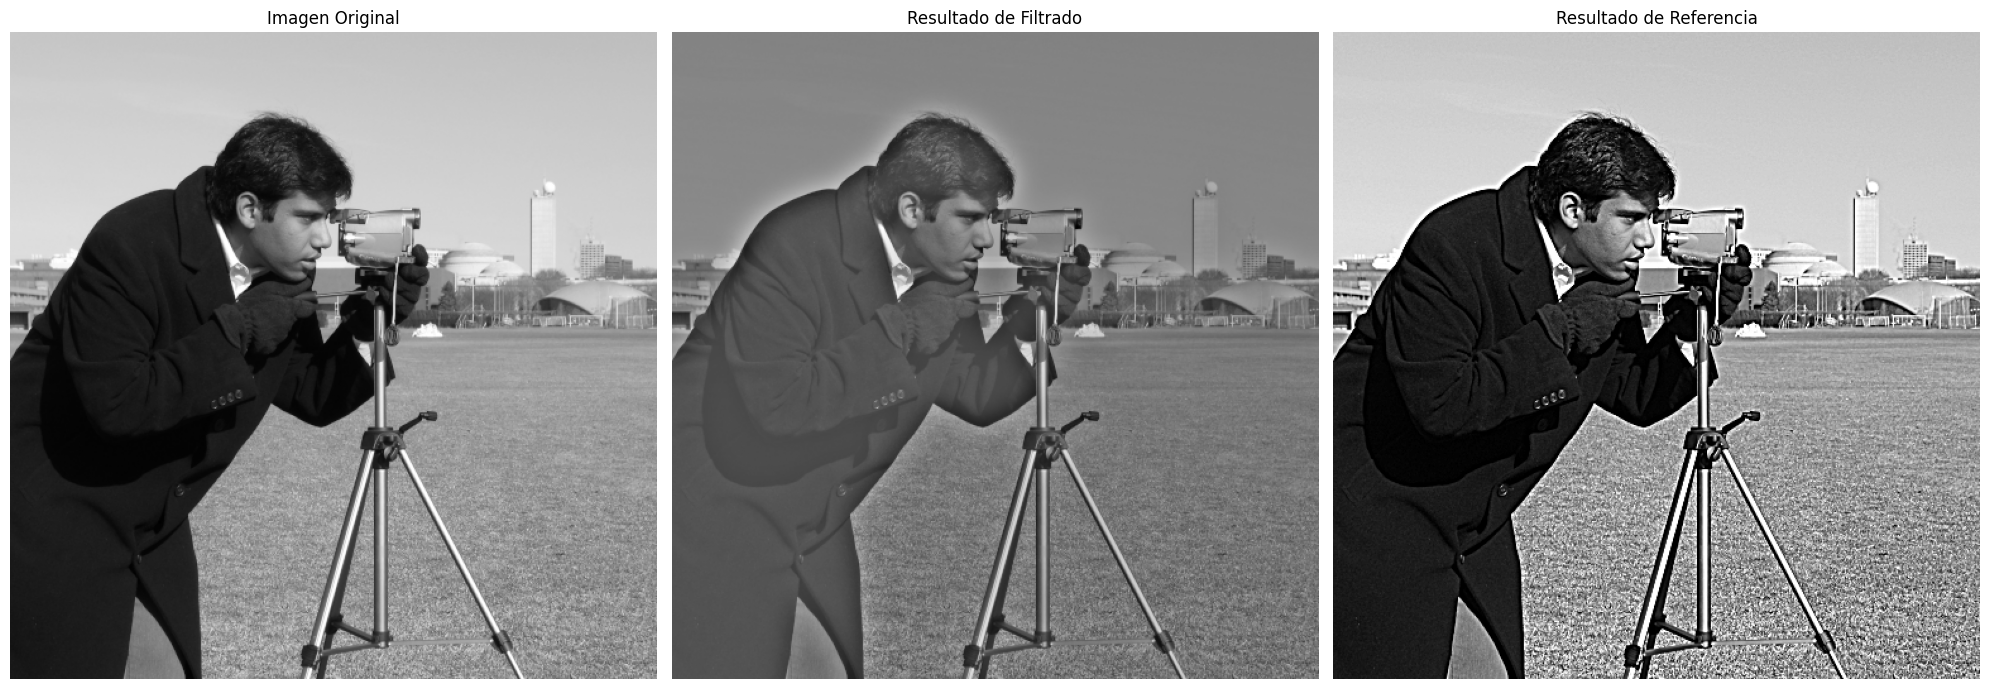

In [41]:

imagenBlancoNegro = util.img_as_float32(data.camera())

# Filtramos la imagen
imagenFiltrada = SharpImage(imagenBlancoNegro)
imagenFiltrada = exposure.rescale_intensity(imagenFiltrada,
                                        in_range=(imagenFiltrada.min(), imagenFiltrada.max()),
                                                  out_range=(0, 1))

# Resultado de referencia
referencia = filters.unsharp_mask(imagenBlancoNegro, radius=2, amount=2)
referencia = exposure.rescale_intensity(referencia,
                                        in_range=(referencia.min(), referencia.max()),
                                                  out_range=(0, 1))

# Mostramos el resultado
fig, axs = plt.subplots(1,3, figsize=(20,10))

axs[0].imshow(imagenBlancoNegro, cmap='gray', clim=(0,1))
axs[0].set_title("Imagen Original")
axs[0].axis("off")

axs[1].imshow(imagenFiltrada, cmap='gray', clim=(0,1))
axs[1].set_title("Resultado de Filtrado")
axs[1].axis("off")


axs[2].imshow(referencia, cmap='gray', clim=(0,1))
axs[2].set_title("Resultado de Referencia")
axs[2].axis("off")

plt.tight_layout()
plt.show()

## **Ruidos**

El ruido es una señal no deseada que se mezcla con una señal útil en cualquier sistema de comunicación o proceso. En procesamiento de imágenes nos enfocaremos principalmente en el ruido Gaussiano y Rayleigh, ambos causados por los sensores utilizados en la obtención de imágenes y con una función de probabilidad clara.


### **Ruido Gaussiano**

$$G(x, y) = \frac{1}{2 \pi \sigma_x \sigma_y} \exp \left( - \frac{1}{2} \left[ \left( \frac{x}{\sigma_x} \right)^2 + \left( \frac{y}{\sigma_y} \right)^2 \right] \right)$$

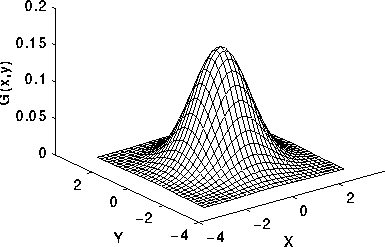

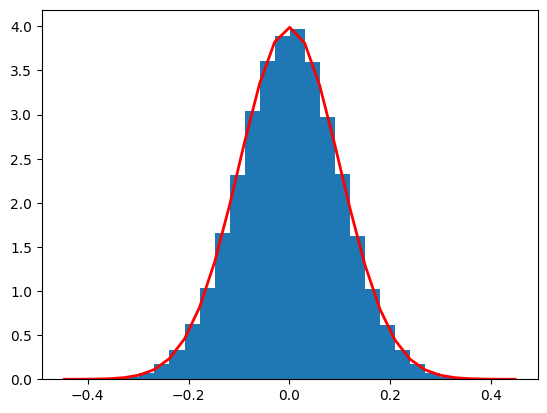

In [42]:
mu, sigma = 0, 0.1
s = np.random.normal(mu, sigma, 100000)

count, bins, ignored = plt.hist(s, 30, density=True)
plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) *
               np.exp( - (bins - mu)**2 / (2 * sigma**2) ),
         linewidth=2, color='r')
plt.show()

### **Ruido Rayleigh**

$$f(r) = \frac{r}{\sigma^2} \exp\left( -\frac{r^2}{2\sigma^2} \right)$$

$$r = \sqrt{x^2+y^2}$$

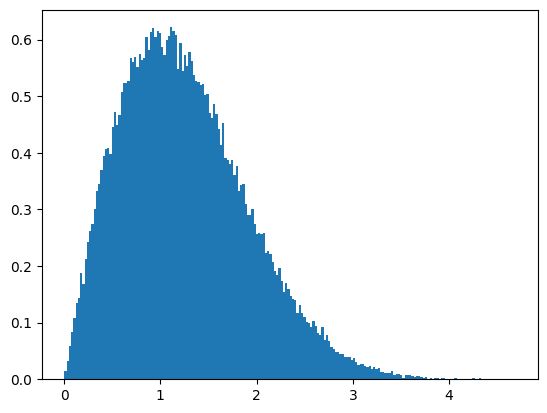

In [43]:
plt.hist(np.random.rayleigh(1, 100000), bins=200, density=True)
plt.show()

### **Efecto de Ruido en Filtros**
Vean como evoluciona la imagen luego de varias operaciones de Sharpening. Hagan el experimento agregando Ruido Gaussiana, Rayleigh y Salt and Pepper


In [44]:
def evolucion(imagenOriginal, aplicaciones):
  evolucionRuido = [imagenOriginal]
  for i in range(aplicaciones):
    imagenBorde = SharpImage(evolucionRuido[i])
    imagenBorde = exposure.rescale_intensity(imagenBorde,
                                           in_range=(imagenBorde.min(), imagenBorde.max()),
                                           out_range=(0, 1))
    evolucionRuido.append(imagenBorde)
  return evolucionRuido

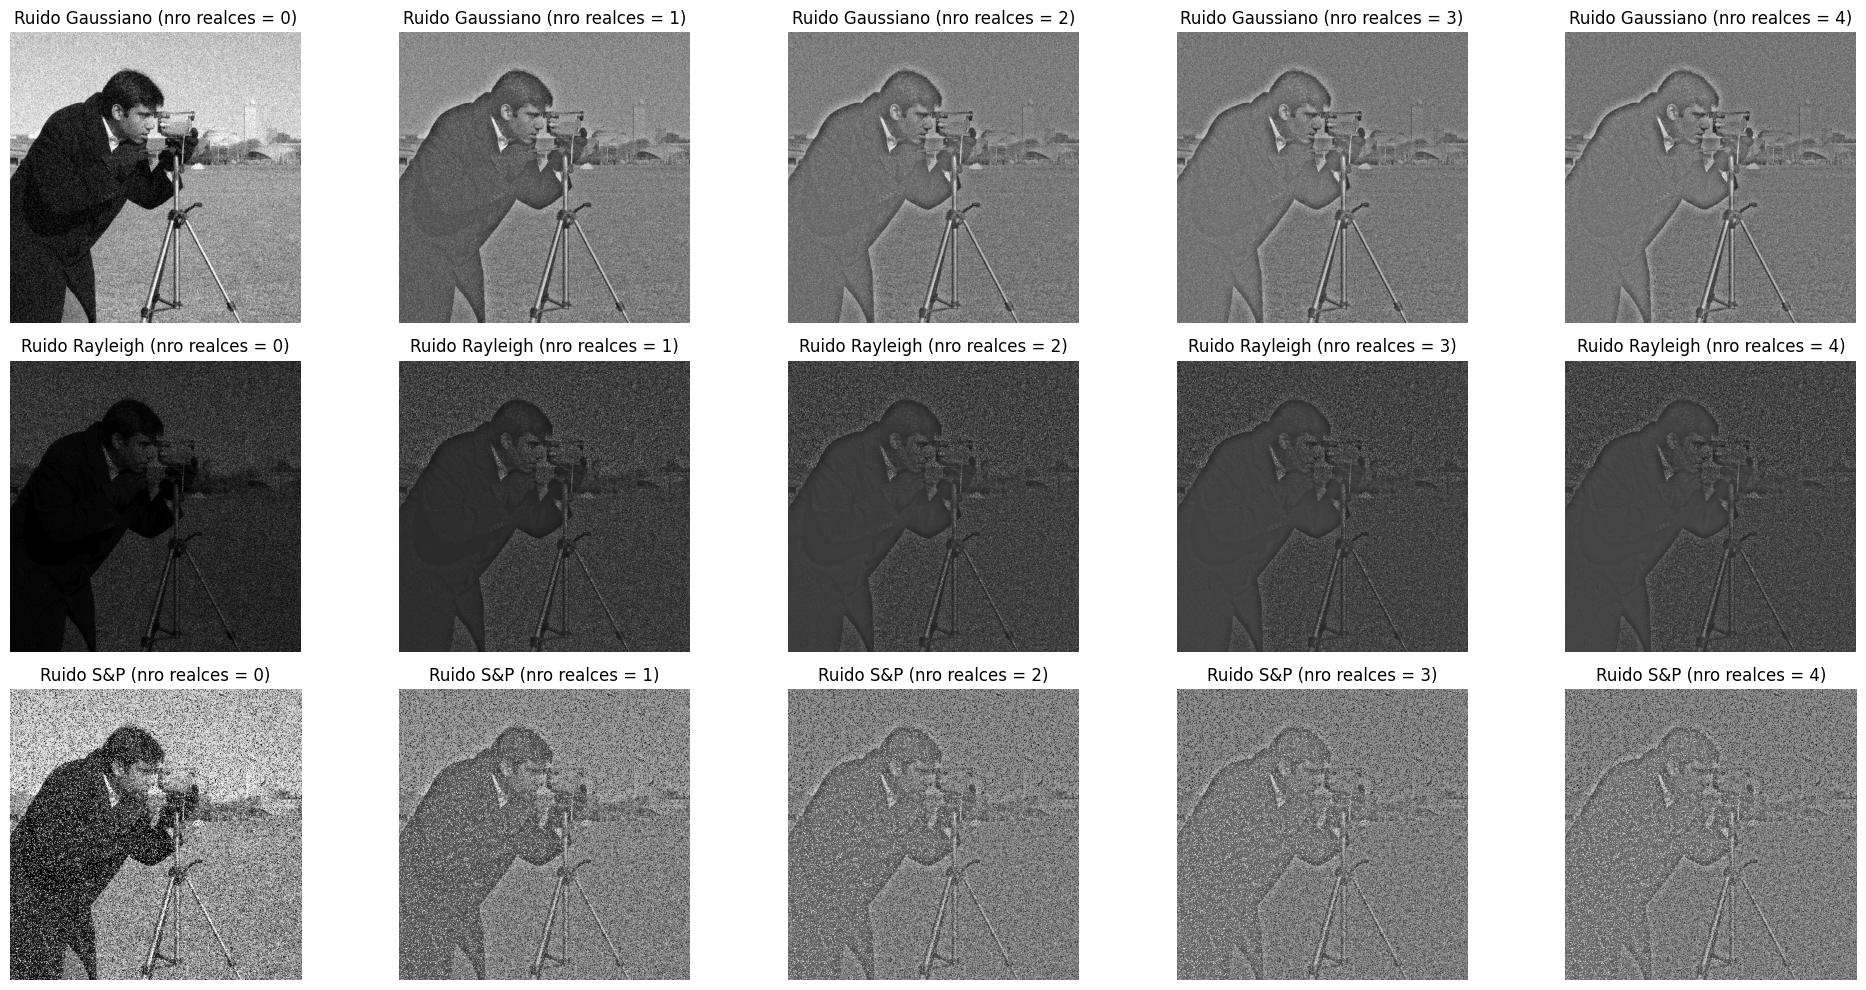

In [45]:
aplicacionesSucesivas = 4

imagenPrueba = util.img_as_float32(data.camera())

# Agregamos ruido Gausseano Aditivo
ImagenConRuidoGausseano = util.random_noise(imagenPrueba, mode='gaussian', mean=0, var=0.01)
#Agregamos ruido Rayleigh Multiplicativo
imagenConRayleigh =  imagenPrueba * np.random.rayleigh(0.2, imagenPrueba.shape)
# Agregamos ruido Gausseano Aditivo
ImagenConSaltAndPepper = util.random_noise(imagenPrueba, mode='s&p', amount=0.3)

# Vemos la evolucion de cada uno
evolucionRuidoG = evolucion(ImagenConRuidoGausseano, aplicacionesSucesivas)
evolucionRayleigh = evolucion(imagenConRayleigh, aplicacionesSucesivas)
evolucionSaltAndPepper = evolucion(ImagenConSaltAndPepper, aplicacionesSucesivas)

fig, axes = plt.subplots(3, aplicacionesSucesivas + 1, figsize=(20, 10))

for i in range(aplicacionesSucesivas + 1):
  axes[0][i].imshow(evolucionRuidoG[i], cmap=plt.cm.gray, clim=(0,1))
  axes[0][i].set_title(f"Ruido Gaussiano (nro realces = {i})")
  axes[0][i].axis("off")


for i in range(aplicacionesSucesivas + 1):
  axes[1][i].imshow(evolucionRayleigh[i], cmap=plt.cm.gray, clim=(0,1))
  axes[1][i].set_title(f"Ruido Rayleigh (nro realces = {i})")
  axes[1][i].axis("off")

for i in range(aplicacionesSucesivas + 1):
  axes[2][i].imshow(evolucionSaltAndPepper[i], cmap=plt.cm.gray, clim=(0,1))
  axes[2][i].set_title(f"Ruido S&P (nro realces = {i})")
  axes[2][i].axis("off")

fig.tight_layout()
plt.show()


## ***CHECKPOINT 2 !!!***

## **Detección de Bordes por Método del Gradiente**


**Implemente los operadores de Roberts, Prewitt y Sobel**

### **Ejercicio 5:** Roberts

In [51]:
def Roberts(image, thresholdBorde):
  k_x = np.array([[1,0],[0,-1]], dtype=float)
  k_y = np.array([[0,1],[-1,0]], dtype=float)

  G_x = ndimage.convolve(image, k_x)
  G_y = ndimage.convolve(image, k_y)

  magnitud = np.sqrt(G_x**2 + G_y**2) / np.sqrt(2)
  magnitud[magnitud < thresholdBorde] = 0

  return magnitud



#### Tests:

In [52]:
class TestRoberts(unittest.TestCase):

    def test_dimensiones(self):
        img = np.random.rand(30, 30).astype(np.float32)
        res = Roberts(img, thresholdBorde=0)
        self.assertEqual(res.shape, img.shape, "Roberts debe retornar una imagen con las mismas dimensiones que la entrada")

    def test_imagen_plana(self):
        # Una imagen constante debe devolver bordes en 0
        img = np.full((25, 25), 0.7, dtype=np.float32)
        res = Roberts(img, thresholdBorde=0)
        np.testing.assert_allclose(res, 0, atol=1e-3, err_msg="En una imagen sin cambios de intensidad, los bordes Roberts deben ser 0")

    def test_threshold(self):
        # Con un umbral alto, bordes suaves deben quedar en 0
        img = np.zeros((30, 30), dtype=np.float32)
        img[:, 15:] = 0.2
        res_con_threshold = Roberts(img, thresholdBorde=0.5)
        np.testing.assert_allclose(res_con_threshold, 0, err_msg="Los bordes con magnitud menor al thresholdBorde deben ser 0")

    def test_comparacion_skimage(self):
        img = data.camera() / 255.0
        res_propio = Roberts(img, thresholdBorde=0)
        res_sk = filters.roberts(img)
        np.testing.assert_allclose(res_propio, res_sk, atol=0.05, err_msg="El resultado sin umbral difiere de skimage.filters.roberts")

if __name__ == '__main__':
    suite = unittest.TestLoader().loadTestsFromTestCase(TestRoberts)
    resultado = unittest.TextTestRunner(verbosity=0).run(suite)
    if resultado.wasSuccessful():
        print("Todos los tests del operador Roberts pasaron correctamente.")
    else:
        print("Algunos tests del operador Roberts fallaron. Revisá la implementación.")


----------------------------------------------------------------------
Ran 4 tests in 0.044s

OK


Todos los tests del operador Roberts pasaron correctamente.


#### **Ejemplo Roberts**

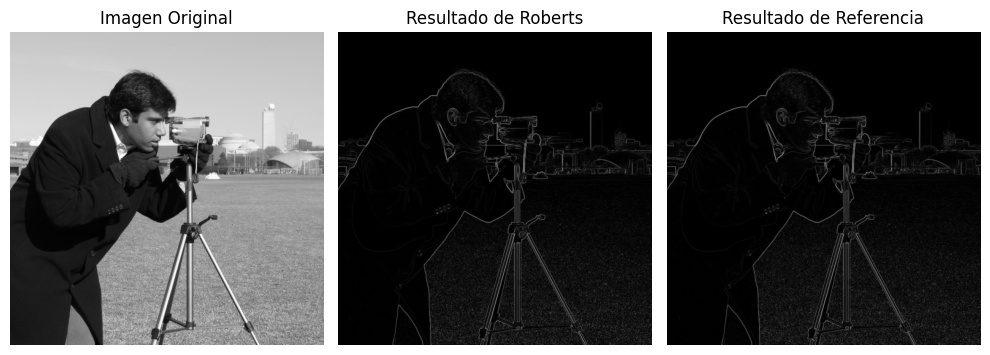

In [53]:
imagenPrueba = util.img_as_float32(data.camera())
imagenBordes = Roberts(imagenPrueba, 0)
imagenBordesSkiImg = filters.roberts(imagenPrueba)
fig, axs = plt.subplots(1, 3, figsize=(10, 10))
axs[0].imshow(imagenPrueba, cmap='gray', clim=(0,1))
axs[0].set_title("Imagen Original")
axs[0].axis("off")
axs[1].imshow(imagenBordes, cmap='gray', clim=(0,1))
axs[1].set_title("Resultado de Roberts")
axs[1].axis("off")
axs[2].imshow(imagenBordesSkiImg, cmap='gray', clim=(0,1))
axs[2].set_title("Resultado de Referencia")
axs[2].axis("off")
fig.tight_layout()
plt.show()


### **Ejercicio 6:** Prewitt

In [58]:
def Prewitt(image, thresholdBorde):

  k_x = np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=float) / 3
  k_y = np.array([[-1,-1,-1],[0,0,0],[1,1,1]], dtype=float) / 3

  G_x = ndimage.convolve(image, k_x)
  G_y = ndimage.convolve(image, k_y)

  magnitud = np.sqrt(G_x**2 + G_y**2) / np.sqrt(2)
  magnitud[magnitud < thresholdBorde] = 0

  return magnitud

#### Tests:

In [59]:
class TestPrewitt(unittest.TestCase):

    def test_dimensiones(self):
        img = np.random.rand(30, 30).astype(np.float32)
        res = Prewitt(img, thresholdBorde=0)
        self.assertEqual(res.shape, img.shape, "Prewitt debe retornar una imagen con las mismas dimensiones que la entrada")

    def test_imagen_plana(self):
        img = np.full((25, 25), 0.3, dtype=np.float32)
        res = Prewitt(img, thresholdBorde=0)
        np.testing.assert_allclose(res, 0, atol=1e-3, err_msg="En una imagen sin gradientes, Prewitt debe devolver 0")

    def test_borde_vertical_y_horizontal(self):
        img_v = np.zeros((20, 20), dtype=np.float32)
        img_v[:, 10:] = 1.0
        res_v = Prewitt(img_v, thresholdBorde=0)
        self.assertGreater(np.max(res_v), 0.5, "Prewitt debe detectar claramente un borde vertical")

        img_h = np.zeros((20, 20), dtype=np.float32)
        img_h[10:, :] = 1.0
        res_h = Prewitt(img_h, thresholdBorde=0)
        self.assertGreater(np.max(res_h), 0.5, "Prewitt debe detectar claramente un borde horizontal")

    def test_threshold(self):
        img = np.zeros((30, 30), dtype=np.float32)
        img[:, 15:] = 0.1
        res = Prewitt(img, thresholdBorde=0.5)
        np.testing.assert_allclose(res, 0, err_msg="Valores por debajo de thresholdBorde deben ser 0")

    def test_comparacion_skimage(self):
        img = data.camera() / 255.0
        res_propio = Prewitt(img, thresholdBorde=0)
        res_sk = filters.prewitt(img)
        np.testing.assert_allclose(res_propio, res_sk, atol=0.05, err_msg="El resultado sin umbral difiere de skimage.filters.prewitt")

if __name__ == '__main__':
    suite = unittest.TestLoader().loadTestsFromTestCase(TestPrewitt)
    resultado = unittest.TextTestRunner(verbosity=0).run(suite)
    if resultado.wasSuccessful():
        print("Todos los tests del operador Prewitt pasaron correctamente.")
    else:
        print("Algunos tests del operador Prewitt fallaron. Revisá la implementación.")


----------------------------------------------------------------------
Ran 5 tests in 0.046s

OK


Todos los tests del operador Prewitt pasaron correctamente.


#### **Ejemplo Prewitt**

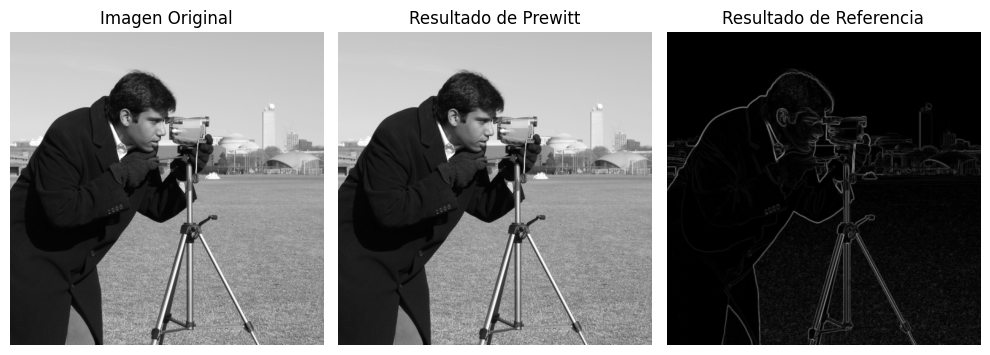

In [29]:
imagenPrueba = util.img_as_float32(data.camera())

imagenBordes = Prewitt(imagenPrueba, 0)
imagenBordesSkiImg = filters.prewitt(imagenPrueba)

fig, axs = plt.subplots(1, 3, figsize=(10, 10))

axs[0].imshow(imagenPrueba, cmap='gray', clim=(0,1))
axs[0].set_title("Imagen Original")
axs[0].axis("off")

axs[1].imshow(imagenBordes, cmap='gray', clim=(0,1))
axs[1].set_title("Resultado de Prewitt")
axs[1].axis("off")

axs[2].imshow(imagenBordesSkiImg, cmap='gray', clim=(0,1))
axs[2].set_title("Resultado de Referencia")
axs[2].axis("off")


fig.tight_layout()
plt.show()

### **Ejercicio 7:** Sobel

In [60]:
def Sobel(image, thresholdBorde):
    k_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=float) / 4
    k_y = np.array([[1,2,1],[0,0,0],[-1,-2,-1]], dtype=float) / 4
  
    G_x = ndimage.convolve(image, k_x)
    G_y = ndimage.convolve(image, k_y)
  
    magnitud = np.sqrt(G_x**2 + G_y**2) / np.sqrt(2)
    magnitud[magnitud < thresholdBorde] = 0
  
    return magnitud

#### Tests:

In [61]:
class TestSobel(unittest.TestCase):

    def test_dimensiones(self):
        img = np.random.rand(30, 30).astype(np.float32)
        res = Sobel(img, thresholdBorde=0)
        self.assertEqual(res.shape, img.shape, "Sobel debe retornar una imagen con las mismas dimensiones que la entrada")

    def test_imagen_plana(self):
        img = np.full((25, 25), 0.5, dtype=np.float32)
        res = Sobel(img, thresholdBorde=0)
        np.testing.assert_allclose(res, 0, atol=1e-3, err_msg="En una imagen plana, Sobel debe devolver 0")

    def test_borde_vertical_y_horizontal(self):
        img_v = np.zeros((20, 20), dtype=np.float32)
        img_v[:, 10:] = 1.0
        res_v = Sobel(img_v, thresholdBorde=0)
        self.assertGreater(np.max(res_v), 0.5, "Sobel debe detectar un borde vertical con alta magnitud")

        img_h = np.zeros((20, 20), dtype=np.float32)
        img_h[10:, :] = 1.0
        res_h = Sobel(img_h, thresholdBorde=0)
        self.assertGreater(np.max(res_h), 0.5, "Sobel debe detectar un borde horizontal con alta magnitud")

    def test_threshold(self):
        img = np.zeros((30, 30), dtype=np.float32)
        img[:, 15:] = 0.1
        res = Sobel(img, thresholdBorde=0.5)
        np.testing.assert_allclose(res, 0, err_msg="Valores por debajo del thresholdBorde deben ser 0")

    def test_comparacion_skimage(self):
        img = data.camera() / 255.0
        res_propio = Sobel(img, thresholdBorde=0)
        res_sk = filters.sobel(img)
        np.testing.assert_allclose(res_propio, res_sk, atol=0.05, err_msg="El resultado sin umbral difiere de skimage.filters.sobel")

if __name__ == '__main__':
    suite = unittest.TestLoader().loadTestsFromTestCase(TestSobel)
    resultado = unittest.TextTestRunner(verbosity=0).run(suite)
    if resultado.wasSuccessful():
        print("Todos los tests del operador Sobel pasaron correctamente.")
    else:
        print("Algunos tests del operador Sobel fallaron. Revisá la implementación.")


----------------------------------------------------------------------
Ran 5 tests in 0.051s

OK


Todos los tests del operador Sobel pasaron correctamente.


#### **Ejemplo Sobel**

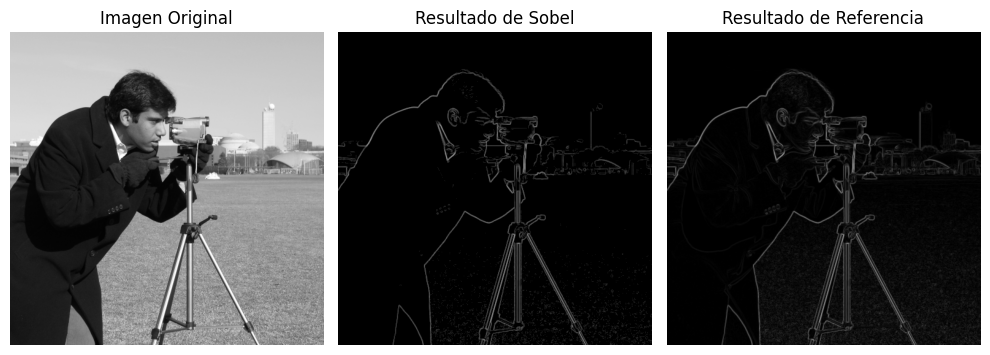

In [62]:
imagenPrueba = util.img_as_float32(data.camera())
imagenBordes = Sobel(imagenPrueba, 0.1)
imagenBordesSkiImg = filters.sobel(imagenPrueba)
fig, axs = plt.subplots(1, 3, figsize=(10, 10))
axs[0].imshow(imagenPrueba, cmap='gray', clim=(0,1))
axs[0].set_title("Imagen Original")
axs[0].axis("off")
axs[1].imshow(imagenBordes, cmap='gray', clim=(0,1))
axs[1].set_title("Resultado de Sobel")
axs[1].axis("off")
axs[2].imshow(imagenBordesSkiImg, cmap='gray', clim=(0,1))
axs[2].set_title("Resultado de Referencia")
axs[2].axis("off")
fig.tight_layout()
plt.show()


## **Efecto de Ruido en la extracción de Bordes**

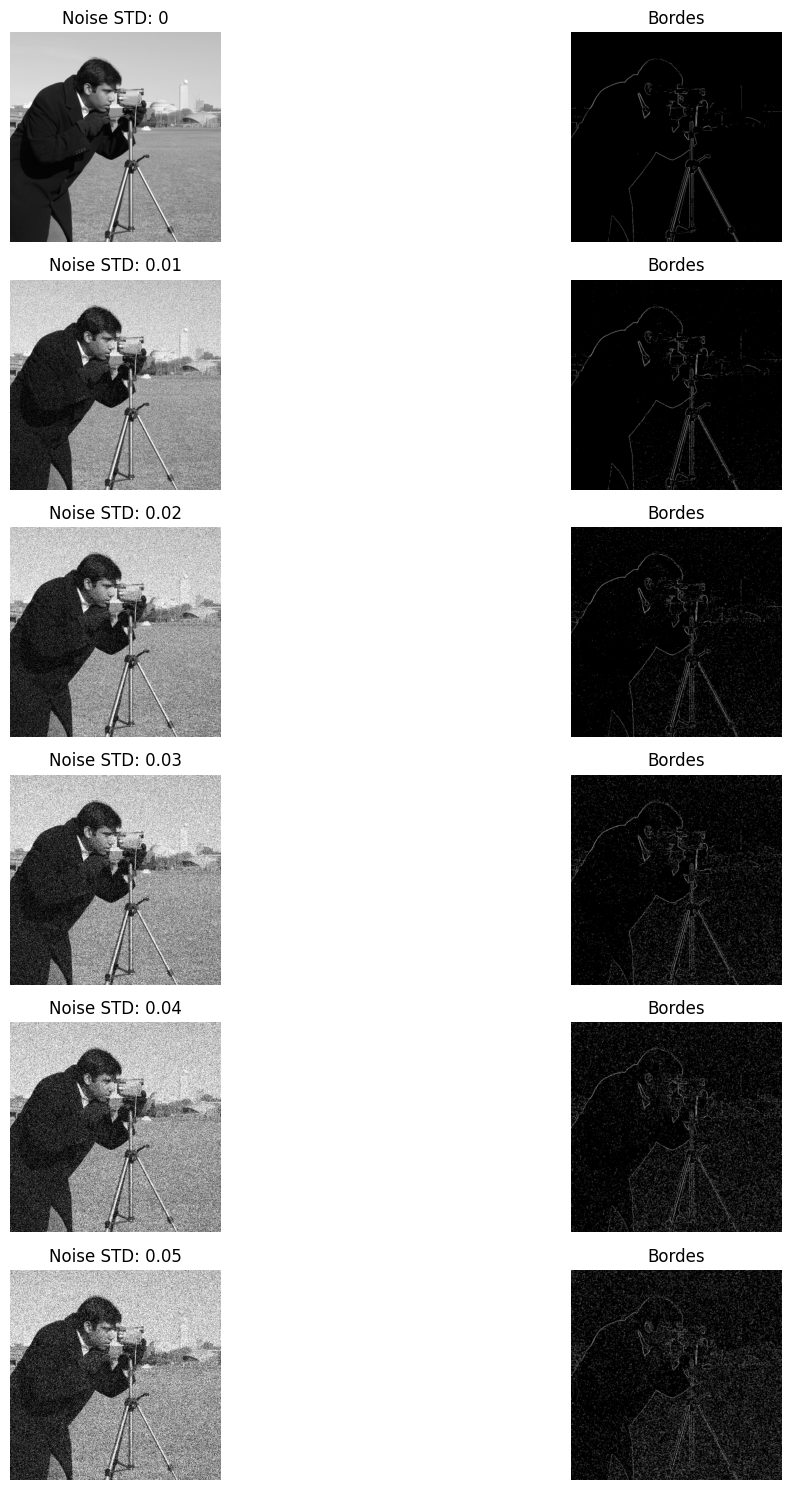

In [63]:
imagenOriginal = util.img_as_float32(data.camera())

# Numero de iteraciones a agregar ruido
iteraciones = 5
# std inicial del ruido
stdInicial = 0.01
# incremento del std por cada iteracion
stdIncremento = 0.01

# Threshold para bordes
threshold = 0.2

# Cargamos como la imagen cambio con el ruido y su resultado con Sobel
evolucionRuido = [imagenOriginal]
evolucionRuidoBordes = [Sobel(imagenPrueba, threshold)]

for i in range(0, iteraciones):
    # Incrementamos la std en cada iteracion
    stdRuido = stdInicial + i * stdIncremento
    imagenRuido = util.random_noise(imagenPrueba, mode='gaussian', mean=0, var=stdRuido)

    evolucionRuido.append(imagenRuido)
    evolucionRuidoBordes.append(Sobel(imagenRuido, threshold))

fig, axs = plt.subplots(iteraciones + 1, 2, figsize=(15, 15))

axs[0][0].imshow(evolucionRuido[0], cmap='gray', clim=(0,1))
axs[0][0].set_title(f"Noise STD: 0")
axs[0][0].axis("off")

axs[0][1].imshow(evolucionRuidoBordes[0], cmap='gray', clim=(0,1))
axs[0][1].set_title("Bordes")
axs[0][1].axis("off")

for i in range(1, iteraciones + 1):
  stdRuido = stdInicial + (i-1) * stdIncremento
  axs[i][0].imshow(evolucionRuido[i], cmap='gray', clim=(0,1))
  axs[i][0].set_title(f"Noise STD: {stdRuido:.2f}")
  axs[i][0].axis("off")

  axs[i][1].imshow(evolucionRuidoBordes[i], cmap='gray', clim=(0,1))
  axs[i][1].set_title("Bordes")
  axs[i][1].axis("off")

plt.tight_layout()
plt.show()


## ***CHECKPOINT 3 !!!***